## pandas / feature engeneering

remembering feature engeneering

In [208]:
import pandas as pd

In [289]:
ds = pd.read_csv('data/Food_Time new.csv')

In [210]:
ds.head()

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


In [211]:
ds.shape

(10000, 17)

In [212]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Traffic_Level                9085 non-null   object 
 1   ID                           10000 non-null  object 
 2   Delivery_person_ID           10000 non-null  object 
 3   weather_description          9995 non-null   object 
 4   Type_of_order                10000 non-null  object 
 5   Type_of_vehicle              10000 non-null  object 
 6   Delivery_person_Age          10000 non-null  int64  
 7   Delivery_person_Ratings      10000 non-null  float64
 8   Restaurant_latitude          10000 non-null  object 
 9   Restaurant_longitude         10000 non-null  object 
 10  Delivery_location_latitude   10000 non-null  object 
 11  Delivery_location_longitude  10000 non-null  object 
 12  temperature                  9995 non-null   float64
 13  humidity         

In [213]:
ds.columns

Index(['Traffic_Level', 'ID', 'Delivery_person_ID', 'weather_description',
       'Type_of_order', 'Type_of_vehicle', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'temperature', 'humidity',
       'precipitation', 'Distance (km)', 'TARGET'],
      dtype='object')

In [214]:
num_cols = ['temperature', 'humidity','precipitation', 'Distance (km)', 'Delivery_person_Age']
cat_cols = ['Traffic_Level', 'weather_description', 'Type_of_order', 'Type_of_vehicle', 'Delivery_person_Ratings']

# I am not sure where to put those
id_cols = ['ID', 'Delivery_person_ID',]
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
target_cols = ['TARGET']

len(num_cols) + len(cat_cols) + len(coord_cols) + len(id_cols) + len(target_cols)

17

### Delivery_person_Ratings

тут в 'Delivery_person_Ratings' значення ніби і float64 але так то дискретні: не можна поставити 4.75 зірок, найменший крок 0.1.
то я подумав шо можна дискретизувати його в проміжки [1, 2), [2, 3) ... [5, 6]

In [215]:
sorted(ds['Delivery_person_Ratings'].unique())

[1.0,
 2.5,
 2.6,
 2.7,
 2.8,
 2.9,
 3.0,
 3.1,
 3.2,
 3.3,
 3.4,
 3.5,
 3.6,
 3.7,
 3.8,
 3.9,
 4.0,
 4.1,
 4.2,
 4.3,
 4.4,
 4.5,
 4.6,
 4.7,
 4.8,
 4.9,
 5.0,
 6.0]

In [217]:
rating_min, rating_max, rating_step = 1, 6, 0.5

rating_map = {}
for i in frange(rating_min, rating_max, rating_step):
  rating_map[(i, i+rating_step)] = []
rating_map
  

{(1, 1.5): [],
 (1.5, 2.0): [],
 (2.0, 2.5): [],
 (2.5, 3.0): [],
 (3.0, 3.5): [],
 (3.5, 4.0): [],
 (4.0, 4.5): [],
 (4.5, 5.0): [],
 (5.0, 5.5): [],
 (5.5, 6.0): [],
 (6.0, 6.5): []}

In [218]:
for i, value in ds['Delivery_person_Ratings'].items():
  
  for value_range in rating_map.keys():
    lim_a, lim_b = value_range
    
    value = float(value)
    
    if value >= lim_a and value < lim_b:
      rating_map[value_range].append(value)
#rating_map

ця мапа зберігає всі значення які попали в її проміжок

In [219]:
sum([len(value_list) for value_list in rating_map.values()])

10000

In [220]:
for key, value in rating_map.items():
  rating_map[key] = len(value)
rating_map

{(1, 1.5): 5,
 (1.5, 2.0): 0,
 (2.0, 2.5): 0,
 (2.5, 3.0): 23,
 (3.0, 3.5): 29,
 (3.5, 4.0): 238,
 (4.0, 4.5): 1534,
 (4.5, 5.0): 7331,
 (5.0, 5.5): 830,
 (5.5, 6.0): 0,
 (6.0, 6.5): 10}

In [221]:
ratings_ranges_df = pd.DataFrame({
  'ranges': rating_map.keys(),
  'amount': rating_map.values(),
})
ratings_ranges_df

,ranges,amount
0,"(1, 1.5)",5
1,"(1.5, 2.0)",0
2,"(2.0, 2.5)",0
3,"(2.5, 3.0)",23
4,"(3.0, 3.5)",29
5,"(3.5, 4.0)",238
6,"(4.0, 4.5)",1534
7,"(4.5, 5.0)",7331
8,"(5.0, 5.5)",830
9,"(5.5, 6.0)",0


в нас дуже незрівноважена змінна, треба думать шо робить.

там знизу на графіку видно шо скачки в даних десь по 0.5 тому розбив дискретизацію по 0.5. нашо? я подумав шо можна не робити всіх окремі класи onehot'ом, а зробити шось типу [1, 3.5), [3.5, 4.5), [4.5, 5.0), [5.0, 6.5) шоб не робити дуже розріджену матрицю

<Axes: >

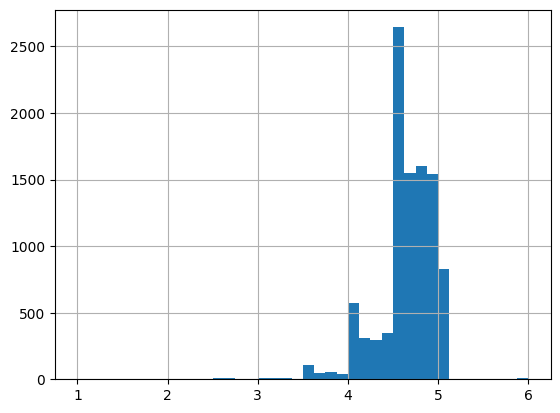

In [222]:
ds['Delivery_person_Ratings'].hist(bins=40)

In [223]:
rating_str_f = lambda lim_a, lim_b: f"Delivery-Person Rating [{lim_a}, {lim_b})"
ds_new_rating = ds.copy()

rating_discrete = [(1, 3.5), (3.5, 4.5), (4.5, 5.0), (5.0, 6.5)]

for lim_a, lim_b in rating_discrete:
  ds_new_rating[rating_str_f(lim_a, lim_b)] = np.zeros(ds.shape[0])

# we use the old 'clean' ds to iterate through but make changes in the new one
for i, value in ds['Delivery_person_Ratings'].items():
  
  for value_range in rating_discrete:
    lim_a, lim_b = value_range
    
    value = float(value)
    
    if value >= lim_a and value < lim_b:
      ds_new_rating[rating_str_f(lim_a, lim_b)][i] = 1


C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\3674172683.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_new_rating[rating_str_f(lim_a, lim_b)][i] = 1
C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\3674172683.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_new_rating[rating_str_f(lim_a, lim_b)][i] = 1
C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\3674172683.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds

In [225]:
ds_new_rating = ds_new_rating.drop('Delivery_person_Ratings', axis=1)
ds_new_rating

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET,"Delivery-Person Rating [1, 3.5)","Delivery-Person Rating [3.5, 4.5)","Delivery-Person Rating [4.5, 5.0)","Delivery-Person Rating [5.0, 6.5)"
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45,0.0,0.0,1.0,0.0
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667,0.0,0.0,1.0,0.0
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667,0.0,1.0,0.0,0.0
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45,0.0,0.0,1.0,0.0
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Very Low,1939,HYDRES05DEL01,haze,Buffet,motorcycle,28,17.433.809,78.386.744,17.443.809,78.396.744,22.61,60.0,0.0,2.52,1.246.666.667,0.0,0.0,1.0,0.0
9996,Very Low,1B05,SURRES14DEL01,mist,Drinks,electric_scooter,26,21.157.729,72.768.726,21.167.729,72.778.726,24.98,73.0,0.0,2.41,20.7,0.0,0.0,1.0,0.0
9997,Very Low,74AB,SURRES05DEL01,mist,Drinks,scooter,32,21.175.104,72.804.342,21.185.104,72.814.342,24.99,73.0,0.0,2.77,20.25,0.0,0.0,1.0,0.0
9998,Very Low,5F66,SURRES02DEL02,mist,Snack,scooter,31,21.186.608,72.794.136,21.206.608,72.814.136,25.01,73.0,0.0,3.42,15.8,0.0,1.0,0.0,0.0


тож я потратив 2 години, шоб почистити одну змінну...

In [373]:
ds['TARGET']

0               43.45
1       3.816.666.667
2       3.636.666.667
3               49.45
4       5.248.333.333
            ...      
9995    1.246.666.667
9996             20.7
9997            20.25
9998             15.8
9999    1.416.666.667
Name: TARGET, Length: 10000, dtype: object

## target

In [378]:
ds_new_target = ds.copy()

In [379]:
# chat wrote this
import math

def convert_to_float(s) -> float:
    if not isinstance(s, str):
        return math.nan  # Return NaN for non-string input
    
    parts = s.split('.')
    if len(parts) > 2:
        s = parts[0] + '.' + ''.join(parts[1:])  # Fix multiple dots
    
    try:
        return float(s)
    except ValueError:
        return math.nan  # Return NaN for invalid float conversion

In [380]:
ds_new_target['TARGET'] = ds_new_target['TARGET'].apply(lambda x: convert_to_float(x))

In [381]:
ds_new_target['TARGET']

0       43.450000
1        3.816667
2        3.636667
3       49.450000
4        5.248333
          ...    
9995     1.246667
9996    20.700000
9997    20.250000
9998    15.800000
9999     1.416667
Name: TARGET, Length: 10000, dtype: float64

господи, бо я вже хто зна шо за ті дані подумав...

In [231]:
ds_new_target[ds_new_target['TARGET'].isna()].count().sort_values()

TARGET                           0
Distance (km)                   45
Traffic_Level                   45
weather_description            955
temperature                    955
humidity                       955
precipitation                  955
Type_of_order                  960
Type_of_vehicle                960
Delivery_person_Age            960
Delivery_person_Ratings        960
ID                             960
Restaurant_longitude           960
Delivery_location_latitude     960
Delivery_location_longitude    960
Delivery_person_ID             960
Restaurant_latitude            960
dtype: int64

видаляти під 1000 записів обіда-боль, але там ж цільова змінна відсутня... можна буде загуглить, може вумні дяді-тьоті, шось там придумали

In [232]:
ds_new_target = ds_new_target.dropna(subset=['TARGET'])

In [233]:
ds_new_target

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.450000
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.450000
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Very Low,1939,HYDRES05DEL01,haze,Buffet,motorcycle,28,4.8,17.433.809,78.386.744,17.443.809,78.396.744,22.61,60.0,0.0,2.52,1.246667
9996,Very Low,1B05,SURRES14DEL01,mist,Drinks,electric_scooter,26,4.7,21.157.729,72.768.726,21.167.729,72.778.726,24.98,73.0,0.0,2.41,20.700000
9997,Very Low,74AB,SURRES05DEL01,mist,Drinks,scooter,32,4.7,21.175.104,72.804.342,21.185.104,72.814.342,24.99,73.0,0.0,2.77,20.250000
9998,Very Low,5F66,SURRES02DEL02,mist,Snack,scooter,31,4.1,21.186.608,72.794.136,21.206.608,72.814.136,25.01,73.0,0.0,3.42,15.800000


## IDS

there are two ID cols. I propose droping both of them as their value does not correspond to the TARGET

In [234]:
ds_new_ids = ds.copy()

In [235]:
ds_new_ids = ds_new_ids.drop(['ID', 'Delivery_person_ID'], axis=1)

In [236]:
ds_new_ids.head()

,Traffic_Level,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


## LATITUDE AND LONGITUDE

In [237]:
# the chatgpt written code
import pandas as pd

def fix_coordinates(coord):
    """
    Convert incorrectly formatted coordinates (with '.' as thousand separators) into floats.
    Validates input to handle NaN values and ensure it's a string.

    Example:
    "13.012.793" -> 13.012793
    "80.289.982" -> 80.289982
    """
    if pd.isna(coord) or not isinstance(coord, str):
        return None  # Return None for NaN values or non-string inputs

    parts = coord.split(".")
    if len(parts) > 2:
        return float(parts[0] + "." + "".join(parts[1:]))
    return float(coord)  # Handle cases where no correction is needed

In [238]:
ds_new_coord = ds.copy()

In [240]:
for coord_col in coord_cols:
  ds_new_coord[coord_col] = ds_new_coord[coord_col].apply(lambda row_value: fix_coordinates(row_value))

In [242]:
ds_new_coord.head()

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972793,80.249982,13.012793,80.289982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369746,8.533982,23.479746,8.544982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327968,78.046106,30.397968,78.116106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856245,73.916619,1.865245,74.006619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426228,78.407495,17.496228,78.477495,21.29,64.0,0.0,18.26,5.248.333.333


## categoricals

In [268]:
cat_cols = ['Traffic_Level','weather_description','Type_of_order','Type_of_vehicle']
cat_cols

['Traffic_Level', 'weather_description', 'Type_of_order', 'Type_of_vehicle']

In [294]:
ds[cat_cols]

,Traffic_Level,weather_description,Type_of_order,Type_of_vehicle
0,3.0,mist,Snack,scooter
1,3.0,clear sky,Meal,scooter
2,3.0,clear sky,Snack,motorcycle
3,3.0,clear sky,Drinks,scooter
4,3.0,overcast clouds,Snack,motorcycle
...,...,...,...,...
9995,0.0,haze,Buffet,motorcycle
9996,0.0,mist,Drinks,electric_scooter
9997,0.0,mist,Drinks,scooter
9998,0.0,mist,Snack,scooter


In [293]:
ds['Traffic_Level'].value_counts()

Traffic_Level
3.0    2736
2.0    2219
4.0    1772
1.0    1726
0.0     632
Name: count, dtype: int64

ЛЕКЦІЇ - 
1. ONE-HOT encoding •Погана підтримка для деяких моделей: Лінійні моделі та нейронні
мережі можуть неефективно працювати з бінарними ознаками.
2. Порядкова заміна •Проблема з нелінійними моделями: Лінійні моделі можуть
неправильно інтерпретувати порядкові коди як абсолютні відстані

from chatgpt:

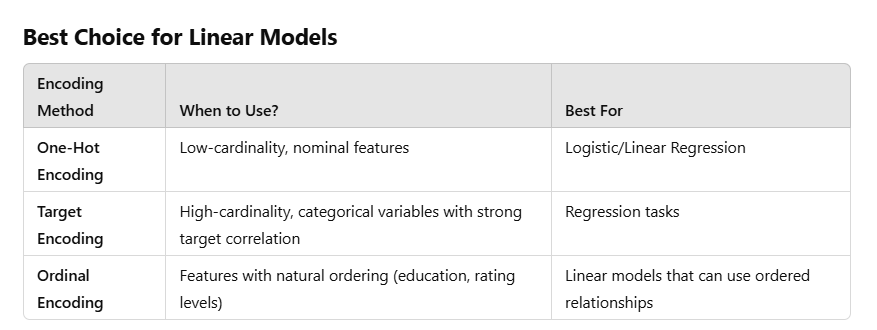

In [292]:
traffic_level_map = {
  'Very High': 4,
  'High': 3,
  'Moderate': 2,
  'Low': 1,
  'Very Low': 0,
}
ds['Traffic_Level'] = ds['Traffic_Level'].map(traffic_level_map)

In [295]:
ds['weather_description'].value_counts()

weather_description
clear sky           3260
haze                2406
mist                1751
broken clouds        721
light rain           536
smoke                501
scattered clouds     422
overcast clouds      308
fog                   49
few clouds            40
moderate rain          1
Name: count, dtype: int64

я спитав в чату: тут погоду не можна подати як ordinal категорії, але можна замінити їх наприклад на видимість і вже тоді впорядкувати

In [ ]:
weather_order_visibility = {
    "clear sky": 11,
    "few clouds": 10,
    "scattered clouds": 9,
    "broken clouds": 8,
    "overcast clouds": 7,
    "haze": 6,
    "mist": 5,
    "fog": 4,
    "smoke": 3,
    "light rain": 2,
    "moderate rain": 1
}
ds['Weather Visibility'] = ds['weather_description'].map(weather_order_visibility)
ds = ds.drop('weather_description', axis=1)

In [303]:
ds.head()

,Traffic_Level,ID,Delivery_person_ID,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET,Weather Visibility
0,3.0,70A2,CHENRES12DEL01,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45,5.0
1,3.0,95B4,RANCHIRES15DEL01,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667,11.0
2,3.0,CDCD,DEHRES17DEL01,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667,11.0
3,3.0,2784,PUNERES13DEL03,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45,11.0
4,3.0,6F67,HYDRES14DEL01,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333,7.0


In [309]:
ds['Type_of_order'].value_counts()

Type_of_order
Snack     2551
Meal      2530
Drinks    2507
Buffet    2412
Name: count, dtype: int64

тут тільки чотири типи, небагато. і порядку в них нема, тому можна за one-hot зробити. target не підійде бо вони плюс-мінус однаково розподілені

In [311]:
ds = pd.get_dummies(ds, columns=['Type_of_order'], drop_first=True)

In [313]:
ds.head()

,Traffic_Level,ID,Delivery_person_ID,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET,Weather Visibility,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack
0,3.0,70A2,CHENRES12DEL01,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45,5.0,False,False,True
1,3.0,95B4,RANCHIRES15DEL01,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667,11.0,False,True,False
2,3.0,CDCD,DEHRES17DEL01,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667,11.0,False,False,True
3,3.0,2784,PUNERES13DEL03,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45,11.0,True,False,False
4,3.0,6F67,HYDRES14DEL01,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333,7.0,False,False,True


In [382]:
cat_cols = [
  'Traffic_Level',
  'Weather Visibility',
  'Type_of_order_Drinks',
  'Type_of_order_Meal',
  'Type_of_order_Snack',
  'Type_of_vehicle_electric_scooter',
  'Type_of_vehicle_motorcycle',
  'Type_of_vehicle_scooter',
]
ds[cat_cols]

KeyError: "['Weather Visibility', 'Type_of_order_Drinks', 'Type_of_order_Meal', 'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter', 'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter'] not in index"

In [322]:
ds['Type_of_vehicle'].value_counts()

Type_of_vehicle
motorcycle          5862
scooter             3304
electric_scooter     814
bicycle               20
Name: count, dtype: int64

тут повторимо те саме 

In [323]:
ds = pd.get_dummies(ds, columns=['Type_of_vehicle'], drop_first=True)

In [324]:
ds

,Traffic_Level,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,...,precipitation,Distance (km),TARGET,Weather Visibility,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,3.0,70A2,CHENRES12DEL01,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,...,0.0,9.89,43.45,5.0,False,False,True,False,False,True
1,3.0,95B4,RANCHIRES15DEL01,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,...,0.0,19.11,3.816.666.667,11.0,False,True,False,False,False,True
2,3.0,CDCD,DEHRES17DEL01,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,...,0.0,11.59,3.636.666.667,11.0,False,False,True,False,True,False
3,3.0,2784,PUNERES13DEL03,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,...,0.0,21.93,49.45,11.0,True,False,False,False,False,True
4,3.0,6F67,HYDRES14DEL01,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,...,0.0,18.26,5.248.333.333,7.0,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,1939,HYDRES05DEL01,28,4.8,17.433.809,78.386.744,17.443.809,78.396.744,22.61,...,0.0,2.52,1.246.666.667,6.0,False,False,False,False,True,False
9996,0.0,1B05,SURRES14DEL01,26,4.7,21.157.729,72.768.726,21.167.729,72.778.726,24.98,...,0.0,2.41,20.7,5.0,True,False,False,True,False,False
9997,0.0,74AB,SURRES05DEL01,32,4.7,21.175.104,72.804.342,21.185.104,72.814.342,24.99,...,0.0,2.77,20.25,5.0,True,False,False,False,False,True
9998,0.0,5F66,SURRES02DEL02,31,4.1,21.186.608,72.794.136,21.206.608,72.814.136,25.01,...,0.0,3.42,15.8,5.0,False,False,True,False,False,True


# combaning what I ve cleaned so far

In [346]:

class FoodTimeCleaner:
  def __init__(self):
    pass
  
  def clean_all(self, df) -> pd.DataFrame:
    num_cols = ['temperature', 'humidity','precipitation', 'Distance (km)', 'Delivery_person_Age']
    cat_cols = ['Traffic_Level', 'weather_description', 'Type_of_order', 'Type_of_vehicle', 'Delivery_person_Ratings']

    # I am not sure where to put those
    id_cols = ['ID', 'Delivery_person_ID',]
    coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
    target_col = 'TARGET'
    
    df = self.clean_ids(df, id_cols)
    df = self.clean_coords(df, coord_cols)
    df = self.clean_target(df, target_col)
    df = self.clean_delivery_person_rating(df, discerete_step=0.5)
    
    df, cat_cols = self.clean_cat(df)
    
    return df
  
  @staticmethod
  def clean_coords(df, coord_cols: list[str]) -> pd.DataFrame:    
    for coord_col in coord_cols:
      df[coord_col] = df[coord_col].apply(lambda row_value: fix_coordinates(row_value))
    return df
    
  @staticmethod
  def clean_ids(df, id_cols: list[str]) -> pd.DataFrame:
    return df.drop(id_cols, axis=1)
  
  @staticmethod
  def clean_target(df, target_col: str) -> pd.DataFrame:
    df[target_col] = df[target_col].apply(lambda x: convert_to_float(x))
    df = df.dropna(subset=[target_col])
    return df
  
  @staticmethod
  def clean_delivery_person_rating(df: pd.DataFrame, discerete_step: float = 0.5) -> pd.DataFrame:
    rating_min, rating_max, discerete_step = 1, 6, 0.5

    rating_map = {}
    for i in frange(rating_min, rating_max, discerete_step):
      rating_map[(i, i+rating_step)] = []
      
    for i, value in df['Delivery_person_Ratings'].items():
      for value_range in rating_map.keys():
        lim_a, lim_b = value_range
        value = float(value)
        if value >= lim_a and value < lim_b:
          rating_map[value_range].append(value)
          
    for key, value in rating_map.items():
      rating_map[key] = len(value)
    
    rating_str_f = lambda lim_a, lim_b: f"Delivery-Person Rating [{lim_a}, {lim_b})"
    rating_discrete = [(1, 3.5), (3.5, 4.5), (4.5, 5.0), (5.0, 6.5)]

    for lim_a, lim_b in rating_discrete:
      df[rating_str_f(lim_a, lim_b)] = np.zeros(df.shape[0])

    # we use the old 'clean' ds to iterate through but make changes in the new one
    for i, value in df['Delivery_person_Ratings'].items():
      for value_range in rating_discrete:
        lim_a, lim_b = value_range
        value = float(value)
        if value >= lim_a and value < lim_b:
          df[rating_str_f(lim_a, lim_b)][i] = 1
          
    for col in [f"Delivery-Person Rating [{lim_a}, {lim_b})" for lim_a, lim_b in [(1, 3.5), (3.5, 4.5), (4.5, 5.0), (5.0, 6.5)]]:
      df[col] = df[col].astype(bool)
    return df.drop('Delivery_person_Ratings', axis=1)
  
  @staticmethod
  def clean_cat(df: pd.DataFrame) -> tuple[pd.DataFrame, list]:
    """_summary_

    Returns:
        tuple[pd.DataFrame, list]: a dataset and new cat_cols
    """
    # Traffic_Level
    traffic_level_map = {
      'Very High': 4,
      'High': 3,
      'Moderate': 2,
      'Low': 1,
      'Very Low': 0,
    }
    df['Traffic_Level'] = df['Traffic_Level'].map(traffic_level_map)
    
    # weather_description
    weather_order_visibility = {
        "clear sky": 11,
        "few clouds": 10,
        "scattered clouds": 9,
        "broken clouds": 8,
        "overcast clouds": 7,
        "haze": 6,
        "mist": 5,
        "fog": 4,
        "smoke": 3,
        "light rain": 2,
        "moderate rain": 1
    }
    df['Weather Visibility'] = df['weather_description'].map(weather_order_visibility)
    df = df.drop('weather_description', axis=1)
    
    df = pd.get_dummies(df, columns=['Type_of_order'], drop_first=True)
    df = pd.get_dummies(df, columns=['Type_of_vehicle'], drop_first=True)
    
    cat_cols = [
      'Traffic_Level',
      'Weather Visibility',
      'Type_of_order_Drinks',
      'Type_of_order_Meal',
      'Type_of_order_Snack',
      'Type_of_vehicle_electric_scooter',
      'Type_of_vehicle_motorcycle',
      'Type_of_vehicle_scooter',
    ]
    
    return df, cat_cols

In [347]:
ds = pd.read_csv('data/Food_Time new.csv')
ds_clean = FoodTimeCleaner().clean_all(ds)

C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\201772336.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[rating_str_f(lim_a, lim_b)][i] = 1
C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\201772336.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[rating_str_f(lim_a, lim_b)][i] = 1
C:\Users\Omen\AppData\Local\Temp\ipykernel_17720\201772336.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[rating_str_f(lim_a, lim_

In [368]:
ds_clean.head()

,Traffic_Level,Delivery_person_Age,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),...,"Delivery-Person Rating [3.5, 4.5)","Delivery-Person Rating [4.5, 5.0)","Delivery-Person Rating [5.0, 6.5)",Weather Visibility,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,3,32,12.972793,80.249982,13.012793,80.289982,26.55,87.0,0.0,9.89,...,False,True,False,5,False,False,True,False,False,True
1,3,33,23.369746,8.533982,23.479746,8.544982,17.51,69.0,0.0,19.11,...,False,True,False,11,False,True,False,False,False,True
2,3,36,30.327968,78.046106,30.397968,78.116106,12.44,77.0,0.0,11.59,...,True,False,False,11,False,False,True,False,True,False
3,3,23,1.856245,73.916619,1.865245,74.006619,19.37,65.0,0.0,21.93,...,False,True,False,11,True,False,False,False,False,True
4,3,34,17.426228,78.407495,17.496228,78.477495,21.29,64.0,0.0,18.26,...,False,True,False,7,False,False,True,False,True,False


In [369]:
ds_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9040 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Traffic_Level                      9040 non-null   int64  
 1   Delivery_person_Age                9040 non-null   int64  
 2   Restaurant_latitude                9040 non-null   float64
 3   Restaurant_longitude               9040 non-null   float64
 4   Delivery_location_latitude         9040 non-null   float64
 5   Delivery_location_longitude        9040 non-null   float64
 6   temperature                        9040 non-null   float64
 7   humidity                           9040 non-null   float64
 8   precipitation                      9040 non-null   float64
 9   Distance (km)                      9040 non-null   float64
 10  TARGET                             9040 non-null   float64
 11  Delivery-Person Rating [1, 3.5)    9040 non-null   bool   
 1

In [370]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Traffic_Level                9085 non-null   object 
 1   ID                           10000 non-null  object 
 2   Delivery_person_ID           10000 non-null  object 
 3   weather_description          9995 non-null   object 
 4   Type_of_order                10000 non-null  object 
 5   Type_of_vehicle              10000 non-null  object 
 6   Delivery_person_Age          10000 non-null  int64  
 7   Delivery_person_Ratings      10000 non-null  float64
 8   Restaurant_latitude          10000 non-null  object 
 9   Restaurant_longitude         10000 non-null  object 
 10  Delivery_location_latitude   10000 non-null  object 
 11  Delivery_location_longitude  10000 non-null  object 
 12  temperature                  9995 non-null   float64
 13  humidity         

ми дуже вдало видалили

In [365]:
distance_median = ds_clean['Distance (km)'].mean()

In [366]:
ds_clean['Distance (km)'] = ds_clean['Distance (km)'].fillna(distance_median)